# Chaine de traitements

Une chaine de traitements (*pipeline*) est composée de différents maillons: on part de données brutes,
rarement exploitables telles quelles, et on les amène jusqu'à une prédiction.

<img src="fig/chaine2.png">

> L'impact des pré-traitements sur la performance finale est souvent bien plus important que le choix du
> modèle lui-même.

**Progression du notebook**: on avance des briques élémentaires vers l'objet industrialisé.

* la partie **A** passe en revue les pré-traitements classiques, un par un, sur de petits jeux de données
  choisis pour que l'effet soit visible: encoder du discret, fabriquer des variables, discrétiser du
  continu, normaliser par colonne puis par individu;
* la partie **B** enchaine tous ces outils *à la main* sur un seul jeu de données réaliste et sale
  (Auto-MPG): valeurs manquantes, colonne textuelle, variables ambigües entre numérique et catégoriel. On y
  gagne des points de performance, mais on y accumule aussi des variables intermédiaires (`X`, `Xnum`, `Xr`,
  `Xtmp`...) que plus personne ne saura reproduire dans six mois;
* la partie **C** apporte la réponse de scikit-learn à ce désordre: l'objet `Pipeline`, qui range toute la
  chaine dans un seul estimateur — apprenable, évaluable, et surtout **optimisable de bout en bout**
  (`GridSearchCV`, Optuna, `ColumnTransformer`);
* la partie **D** propose des exercices complémentaires indépendants.

**Le fil rouge à garder en tête**: un pré-traitement s'*apprend* sur les données d'apprentissage
(`fit`) puis s'*applique* aux nouvelles données (`transform`). Toute entorse à cette règle produit une
mesure de performance fausse. Les parties A et B la respectent approximativement, la partie C la rend
impossible à violer.

**Conventions**: les cellules à compléter sont signalées par un commentaire `TODO` dans la version
étudiante ; les blocs <span style="color:red">Mini-exo</span> sont de courts exercices d'application
immédiate.

<a id="sec-plan"></a>
## Plan

* [A. Transformer les variables de description](#sec-a)
    * [A.1 Enrichissement et transformation des données](#sec-a1)
        * [A.1.1 Encodage des variables discrètes](#sec-a11)
        * [A.1.2 Création de nouvelles variables](#sec-a12)
        * [A.1.3 Discrétisation de variables continues](#sec-a13)
    * [A.2 Normalisation des données (par colonne)](#sec-a2)
    * [A.3 Normalisation par individu (par ligne)](#sec-a3)
* [B. Étude approfondie du cas Auto-MPG](#sec-b)
    * [B.1 La gestion des données manquantes](#sec-b1)
    * [B.2 Analyse du contenu des colonnes](#sec-b2)
    * [B.3 Performance de référence, puis enrichissement](#sec-b3)
    * [B.4 Discrétisation d'une variable continue](#sec-b4)
    * [B.5 Transformations arbitraires (métier)](#sec-b5)
    * [B.6 Passage à un modèle de l'état de l'art](#sec-b6)
* [C. Construire une chaine de traitements en scikit-learn](#sec-c)
    * [C.1 Une première chaine: sélection de caractéristiques + SVM](#sec-c1)
    * [C.2 Deuxième chaine: ACP + arbre de décision](#sec-c2)
    * [C.3 Optimiser la chaine avec `GridSearchCV`](#sec-c3)
    * [C.4 Optimiser la chaine avec Optuna](#sec-c4)
        * [C.4.1 Le problème d'optimisation, sans optimisation](#sec-c41)
        * [C.4.2 Une recherche qui brise la combinatoire](#sec-c42)
        * [C.4.3 Hyper-paramètres conditionnels au modèle](#sec-c43)
    * [C.5 Exercice: chaine complète sur les vins](#sec-c5)
    * [C.6 Colonnes hétérogènes: `ColumnTransformer`](#sec-c6)
* [D. Exercices complémentaires](#sec-d)
    * [D.1 `fit` sur l'apprentissage, `transform` sur le test](#sec-d1)
    * [D.2 Auto-MPG en une seule chaine](#sec-d2)
    * [D.3 Variables catégorielles à haute cardinalité](#sec-d3)
    * [D.4 Transformer la cible, pas seulement les entrées](#sec-d4)
    * [D.5 Écrire son propre transformateur](#sec-d5)
    * [D.6 Que vaut vraiment la performance annoncée?](#sec-d6)
* [Annexe: transformation du notebook en version étudiante](#sec-annexe)

In [193]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # messages de dépréciation sklearn/pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from outils.frontiere import *
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, cross_val_score

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<a id="sec-a"></a>
## A. Transformer les variables de description

Les données brutes sont rarement directement exploitables: elles sont incomplètes, bruitées, parfois
codées dans des formats que les algorithmes ne savent pas lire (du texte, des catégories), parfois dans
des échelles incompatibles entre elles.

Cette partie passe en revue les transformations les plus classiques, **une par une**, chacune sur un jeu de
données choisi pour que son effet soit spectaculaire. L'objectif n'est pas de traiter un vrai problème (ce
sera la partie B) mais de bien voir *ce que fait* chaque outil, et *pourquoi* il est nécessaire.

<a id="sec-a1"></a>
### A.1 Enrichissement et transformation des données

Trois situations, dans l'ordre: la variable n'est pas numérique (A.1.1), la variable est numérique mais
l'information utile n'est pas directement lisible par le modèle (A.1.2), la variable est continue mais
mieux exploitée sous forme de tranches (A.1.3).

<a id="sec-a11"></a>
#### A.1.1 Encodage des variables discrètes

Les variables descriptives sont souvent discrètes (`'premeno'`, `'left_up'`, `'ge40'`...). Or les approches
de machine learning ne savent pas gérer ces informations telles quelles: elles calculent des produits
scalaires et des distances, ce qui n'a aucun sens sur des chaines de caractères (seuls certains arbres font
exception).

La solution standard est l'encodage **one-hot** (ou *disjonctif complet*): une colonne à $k$ modalités est
remplacée par $k$ colonnes binaires.
[doc `OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

1. Charger des données discrètes: prédiction de récidive de cancer du sein
2. Afficher les 3 premières lignes — et bien comprendre en quoi ces données diffèrent de tout ce que nous
   avons manipulé jusqu'ici
3. Transformer les données, puis mesurer une performance

In [194]:
# Récupération de données 100% discrètes (chaines de caractères)

filename = "data/breast-cancer.csv"
data = pd.read_csv(filename, header=None).values  # pas d'en-tête dans ce fichier

Xbrut = data[:,:-1]    # 9 variables descriptives, toutes catégorielles
Ybrut = data[:,-1:]    # la cible, elle aussi textuelle: recurrence-events / no-recurrence-events

print("Descriptions :\n", Xbrut[:3,:])
print("Etiquettes   :\n", Ybrut[:3])

Descriptions :
 [["'40-49'" "'premeno'" "'15-19'" "'0-2'" "'yes'" "'3'" "'right'"
  "'left_up'" "'no'"]
 ["'50-59'" "'ge40'" "'15-19'" "'0-2'" "'no'" "'1'" "'right'" "'central'"
  "'no'"]
 ["'50-59'" "'ge40'" "'35-39'" "'0-2'" "'no'" "'2'" "'left'" "'left_low'"
  "'no'"]]
Etiquettes   :
 [["'recurrence-events'"]
 ["'no-recurrence-events'"]
 ["'recurrence-events'"]]


In [195]:
# Transformation one-hot des descriptions ET de la cible
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(Xbrut)                       # fit = recensement des modalités de chaque colonne
X = enc.transform(Xbrut)             # transform = construction effective des colonnes binaires

print("Catégories trouvées, colonne par colonne: \n", enc.categories_)

# Même opération pour Y (tout en une ligne avec fit_transform).
# Y textuel à 2 modalités -> 2 colonnes; on n'en garde qu'une, l'autre en est le complément.
# ATTENTION: [:,0] désigne la 1ère modalité dans l'ordre alphabétique, ici 'no-recurrence-events'.
enc2 = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
Y = enc2.fit_transform(Ybrut)[:,0]

print("Classe codée par Y=1 :", enc2.categories_[0][0])
print("Echantillon transformé: \n", X[:3,:], Y[:3])
print("Comparaison des dimensions (9 colonnes -> 43): \n", Xbrut.shape, X.shape)

Catégories trouvées, colonne par colonne: 
 [array(["'20-29'", "'30-39'", "'40-49'", "'50-59'", "'60-69'", "'70-79'"],
      dtype=object), array(["'ge40'", "'lt40'", "'premeno'"], dtype=object), array(["'0-4'", "'10-14'", "'15-19'", "'20-24'", "'25-29'", "'30-34'",
       "'35-39'", "'40-44'", "'45-49'", "'5-9'", "'50-54'"], dtype=object), array(["'0-2'", "'12-14'", "'15-17'", "'24-26'", "'3-5'", "'6-8'",
       "'9-11'"], dtype=object), array(["'no'", "'yes'", nan], dtype=object), array(["'1'", "'2'", "'3'"], dtype=object), array(["'left'", "'right'"], dtype=object), array(["'central'", "'left_low'", "'left_up'", "'right_low'",
       "'right_up'", nan], dtype=object), array(["'no'", "'yes'"], dtype=object)]
Classe codée par Y=1 : 'no-recurrence-events'
Echantillon transformé: 
 [[0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
  0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.


In [196]:
# Analyse et performances: les données sont maintenant numériques, donc exploitables
from sklearn.model_selection import cross_val_score

mod    = SVC(kernel="linear")
n_fold = 5
scores = cross_val_score(mod, X, Y, cv=n_fold, scoring='accuracy')  # apprentissage + évaluation en 1 ligne
print("accuracy par pli :", scores.round(3), "| moyenne :", scores.mean().round(3))

accuracy par pli : [0.69  0.737 0.719 0.754 0.667] | moyenne : 0.713


#### <span style="color:red">Mini-exo</span> quelle classe met-on en positif? [Préliminaire facultatif, déjà traité précédemment]

Le TP précédent sur les métriques nous a appris à nous méfier de l'accuracy sur des classes déséquilibrées.
La cellule ci-dessous vérifie la balance, puis calcule un F1.

1. Regarder l'équilibre des classes, puis le F1 obtenu: peut-on conclure que le modèle *va bien*?
2. Recalculer le F1 en prenant `[:,1]` au lieu de `[:,0]` dans l'encodage de `Y`, c'est-à-dire en mettant
   en classe positive la récidive (`recurrence-events`) — la classe rare, et la seule qui intéresse le
   médecin. Que devient le score?
3. Calculer enfin la `balanced_accuracy`, qui ne dépend pas de ce choix

In [197]:

# 2. refaire EXACTEMENT le même calcul de F1, en changeant seulement la colonne retenue au moment
#    de l'encodage de Y (cf. cellule plus haut: enc2.fit_transform(Ybrut)[:,0] -> [:,1])
# 3. puis, pour les deux codages, remplacer scoring='f1' par scoring='balanced_accuracy'
#    (une boucle sur les deux versions de Y évite de dupliquer le code) => 4 à 6 lignes attendues

for k in range(2):
    Y = enc2.fit_transform(Ybrut)[:,k]
    # Balance des étiquettes: 201 vs 85, c'est nettement déséquilibré
    val, cnt = np.unique(Y, return_counts=True)
    print("répartition des classes :", dict(zip(val.astype(int), cnt)))

    # F1 sur la classe positive telle qu'elle est codée pour l'instant (= no-recurrence, la classe majoritaire)
    scores = cross_val_score(mod, X, Y, cv=n_fold, scoring='f1')
    print("f1 (positif = %s) : %.3f" % (enc2.categories_[0][0], scores.mean()))


répartition des classes : {np.int64(0): np.int64(85), np.int64(1): np.int64(201)}


f1 (positif = 'no-recurrence-events') : 0.810
répartition des classes : {np.int64(0): np.int64(201), np.int64(1): np.int64(85)}
f1 (positif = 'no-recurrence-events') : 0.415


Réponse:

 TODO 

<a id="sec-a12"></a>
#### A.1.2 Création de nouvelles variables

Le modèle ne voit que ce qu'on lui donne. Si l'information utile est présente mais *encodée d'une manière
qu'il ne sait pas lire*, il échoue — et la solution n'est pas de changer de modèle, mais d'ajouter la bonne
variable.

L'exemple canonique est l'échiquier: deux classes en damier, parfaitement structurées, mais qu'aucune droite
ne peut séparer. Si on ajoute un descripteur qui vaut $\pm 1$ selon la parité de la case, le problème
devient linéairement séparable.

dimensions : (100, 2) | ~4 points par case


Text(0.5, 1.0, 'Échiquier: 2 classes en damier')

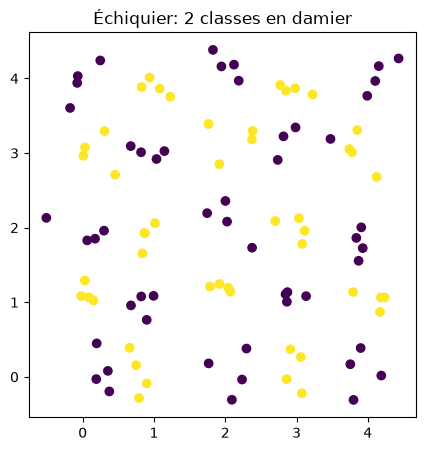

In [198]:
# Génération des données: 25 gaussiennes très serrées, disposées sur une grille 5x5
centers      = [[float(i),float(j)] for i in range(5) for j in range(5)]
clusters_std = 0.2
X, y = make_blobs(n_samples=100, centers=centers, cluster_std=clusters_std, n_features=2, random_state=0)

y = (y % 2)*2 - 1   # 1 centre = 1 "classe" au départ -> on les regroupe par parité = échiquier binaire

print("dimensions :", X.shape, "| ~%d points par case" % (len(X)/len(centers)))
plt.figure(facecolor='white', figsize=[5,5])
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Échiquier: 2 classes en damier")

Scores :  [0.5 0.5 0.3 0.5 0.4] | moyenne : 0.44


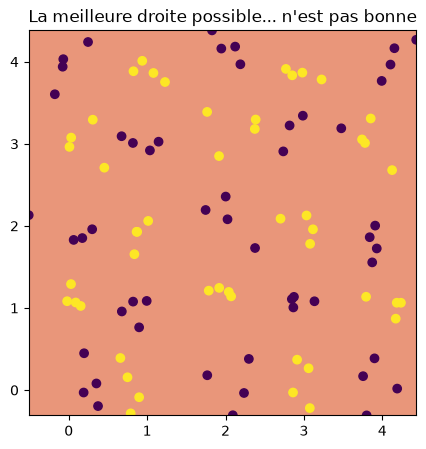

In [199]:
# Construction d'un classifieur linéaire sur les 2 variables brutes

mod = svm.SVC(kernel="linear")
mod.fit(X,y)

plt.figure(facecolor='white', figsize=[5,5])
plot_frontiere(X,y,mod)
plt.scatter(X[:,0],X[:,1],c=y)
plt.title("La meilleure droite possible... n'est pas bonne")
# plt.savefig("fig/checkers.pdf")

sc = cross_val_score(mod, X, y)
print("Scores : ", sc.round(2), "| moyenne : %.2f" % sc.mean())

# => les données ne sont pas séparables linéairement: on est au niveau du hasard.
#    Un noyau gaussien ne sauve rien non plus ici (4 points par case, c'est trop peu pour l'apprendre).

Scores :  [0.75 0.85 0.9  0.8  0.85] | moyenne : 0.83


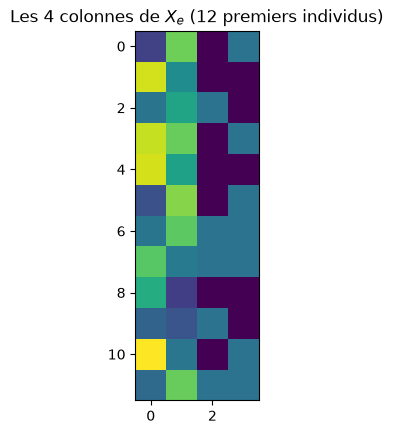

In [200]:
# Ajout de deux variables "métier": la parité de la case en x et en y
# (+0.5 pour recentrer: les centres sont en 0,1,2... donc les frontières de cases sont en 0.5,1.5,...)

Xi = np.reshape([(np.floor(i)%2)*2-1 for i in X[:,0]+0.5], (-1,1))   # parité de la colonne de l'échiquier
Xj = np.reshape([(np.floor(i)%2)*2-1 for i in X[:,1]+0.5], (-1,1))   # parité de la ligne

Xe = np.concatenate((X,Xi,Xj), axis = 1)   # 2 dimensions d'origine + 2 dimensions construites

plt.figure(facecolor='white')
plt.imshow(Xe[:12,:])   # visualisation des 12 premières lignes: les 2 colonnes de droite sont binaires
plt.title("Les 4 colonnes de $X_e$ (12 premiers individus)")
# plt.savefig("fig/checkers_Xe.pdf")

sc = cross_val_score(mod, Xe, y)
print("Scores : ", sc.round(2), "| moyenne : %.2f" % sc.mean())

# => même modèle, même données, +2 colonnes: on passe du hasard (~0.44) à ~0.83.
#    Toute l'intelligence est dans la construction de variables, pas dans le classifieur.

<a id="sec-a13"></a>
#### A.1.3 Discrétisation de variables continues

L'opération inverse de A.1.1: il est parfois difficile de tirer parti d'une variable continue, et plus
simple de créer des variables encodant l'appartenance à un **segment** de valeurs. C'est typiquement le cas
quand la distribution est très irrégulière, ou quand le lien entre la variable et la cible n'est pas
monotone.

Exemple: des données étalées entre 1 et 10, avec

* peu de points, uniformément répartis entre 1 et 5
* beaucoup de points centrés en 7.5, avec une faible dispersion
* beaucoup de points centrés en 9, avec une faible dispersion

$\Rightarrow$ ce type de distribution déstabilise les approches de ML (une régression linéaire va être
tirée par les deux paquets de droite et ignorer totalement la zone de gauche).

1. La fonction qui permet de faire cela est
   [`KBinsDiscretizer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.KBinsDiscretizer.html)
2. Générer les données décrites ci-dessus et tester cette fonction. Bien regarder les arguments `n_bins`,
   `strategy` (`'uniform'` = tranches de même largeur, `'quantile'` = tranches de même effectif) et `encode`
3. [OPT] Réfléchir au pont entre modèle linéaire et arbres de décision

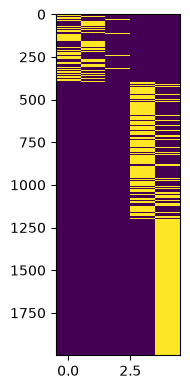

In [201]:
from sklearn.preprocessing import KBinsDiscretizer

# 1. générer des données 1D correspondant à la description ci-dessus
#    np.random.uniform(1,5,30) pour le paquet étalé, 7.5 + 0.2*np.random.randn(120) pour les paquets serrés
#    np.concatenate(...) puis .reshape(-1,1): sklearn attend une MATRICE (n,1), pas un vecteur
#    un plt.hist permet de vérifier qu'on a bien la distribution décrite
# 2. tester la fonction et afficher la matrice créée
#    KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy=...) puis fit_transform
#    comparer les deux strategy: regarder enc.bin_edges_ (les bornes) et l'effectif de chaque tranche
#    (= la somme de chaque colonne de la matrice one-hot obtenue)
#    la matrice elle-même se visualise bien avec plt.imshow(..., aspect='auto')

###  TODO  ###
n = 2000
X1 = np.random.random((1,(n//5))).reshape(1,-1)*4 + 1
X2 = np.random.rand(2*n//5).reshape(1,-1) + 7.5
X3 = np.random.rand(2*n//5).reshape(1,-1) + 9

X = np.hstack((X1,X2,X3)).reshape(-1,1) #(200,1)

K = KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='uniform')
Xt = K.fit_transform(X)

plt.figure(facecolor='white', figsize=(2,4))
plt.imshow(Xt, aspect='auto', interpolation='nearest')
plt.tight_layout()
plt.show()

[OPT] Le pont entre modèle linéaire et arbres:

 TODO 

<a id="sec-a2"></a>
### A.2 Normalisation des données (par colonne)

Soit des données tabulaires classiques:
$$X = \begin{pmatrix}  x_{11}& x_{12} &  \ldots & x_{1d}  \\
x_{21}& x_{22} & \ldots & x_{2d} \\
\vdots& \vdots & \ddots &\vdots \\
x_{n1}& x_{n2} & \ldots & x_{nd}  \\
\end{pmatrix} ,\qquad
Y = \begin{pmatrix}  y_{1} \\
y_{2}\\
\vdots\\
y_{n} \\
\end{pmatrix} ,\qquad y_i\in \mathcal Y
$$

Dans la plupart des cas, le problème vient des colonnes $X_j$:

* elles ne sont pas codées dans les mêmes échelles: colonne $i$ en $10^{-5}$, colonne $j$ en $10^{-9}$;
* ou elles ont simplement un biais trop important, e.g. des valeurs entre $1050$ et $1070$.

Les algorithmes de ML sont souvent déstabilisés par ces écarts de valeur — tous ceux qui reposent sur une
distance ou un produit scalaire (SVM, $k$-ppv, régression régularisée, réseaux de neurones) laissent la
colonne de plus grande amplitude écraser les autres. Il faut normaliser pour obtenir de bonnes performances.

On utilise presque toujours une normalisation standard gaussienne, qui consiste à centrer et réduire chaque
colonne: $\tilde{X}_j = (X_j - \mu_j)/\sigma_j \sim \mathcal N(0,1)$.

[doc `StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

**Le point de vigilance**, sur lequel tout le notebook va revenir: $\mu_j$ et $\sigma_j$ sont **estimés sur
les données d'apprentissage** (`fit`) et **réutilisés tels quels** sur les données de test (`transform`).

In [202]:
# Un jeu de données où les colonnes n'ont visiblement rien à voir en termes d'échelle
filename = "data/winequality-red.csv"
data = pd.read_csv(filename)

data.describe().loc[['mean','std','min','max']].round(2)   # comparer les lignes mean et std !

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


In [203]:
# Comparaison des performances avec et sans normalisation
from sklearn.preprocessing import StandardScaler

X = data.values[:,:-1]     # 11 mesures physico-chimiques
Y = data.values[:,-1]      # la note de qualité (3 à 8)

# remise en forme des Y entre 0 et nClasses-1
val    = np.unique(Y)
transf = dict(zip(val, np.arange(len(val))))   # mapping [3,4,...,8] => [0,1,...,5]
Y      = np.vectorize(transf.get)(Y)           # application de la transformation

mod = SVC()
sc  = cross_val_score(mod, X, Y, scoring='accuracy')
print("Scores bruts                 ", sc.round(3), "| moyenne : %.3f" % sc.mean())

scal = StandardScaler()
Xn   = scal.fit_transform(X)
# 1. Appliquer la transformation (cf doc) et remplacer cette ligne
#    une seule ligne suffit: fit calcule la moyenne et l'écart-type de chaque colonne,
#    transform les applique... et fit_transform fait les deux d'un coup



# 2. la performance se recalcule à l'identique, sur les nouvelles données
sc = cross_val_score(mod, Xn, Y, scoring='accuracy')
print("Scores sur données normalisées", sc.round(3), "| moyenne : %.3f" % sc.mean())
# => environ +9 points d'accuracy, sans changer une seule ligne du modèle.

Scores bruts                  [0.569 0.534 0.475 0.456 0.476] | moyenne : 0.502
Scores sur données normalisées [0.556 0.547 0.653 0.6   0.592] | moyenne : 0.590


**Question d'ouverture**: l'impact de la normalisation est-il le même sur tous les classifieurs?

Tester la cellule suivante (XGBoost, un ensemble d'arbres de décision) avant de répondre.

In [204]:
import xgboost as xgb   # !pip install xgboost # en cas de besoin

bst = xgb.XGBClassifier()
sc  = cross_val_score(bst, X,  Y, scoring='accuracy')
print("xgboost (brut)     : ", sc.round(3), "| moyenne : %.3f" % sc.mean())

sc = cross_val_score(bst, Xn, Y, scoring='accuracy')
print("xgboost (normalisé): ", sc.round(3), "| moyenne : %.3f" % sc.mean())

xgboost (brut)     :  [0.5   0.522 0.534 0.562 0.545] | moyenne : 0.533
xgboost (normalisé):  [0.5   0.522 0.534 0.562 0.545] | moyenne : 0.533


Réponse:

Aucune modification car XGBoost n'est pas sujet aux problème d'echele

<a id="sec-a3"></a>
### A.3 Normalisation par individu (par ligne)

Attention à ne pas confondre avec la précédente: en A.2 on normalisait les **colonnes** pour les rendre
comparables entre elles. Ici il est question de normaliser les **lignes**, pour rendre les individus
comparables entre eux.

C'est indispensable sur les applications où l'*intensité globale* d'un individu est un artefact de mesure,
et non une information:

* un texte de 100 mots et un texte de 1000 mots ne sont pas comparables en comptes bruts;
* les logs de la station Châtelet un jour de semaine ne sont pas comparables avec un week-end.

Les deux normalisations les plus connues sont:

1. la normalisation **probabiliste** (les variables d'un individu somment à 1): on fait une hypothèse
   multinomiale sur les variables — pour le texte notamment. C'est
   [`Normalizer(norm='l1')`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.Normalizer.html),
   le seul objet de `preprocessing` qui travaille **ligne par ligne**;
2. la normalisation **min-max** ramenée dans $[0,1]$: souvent pour les signaux.

Évidemment, en fonction de l'application visée, cela peut être utile ou au contraire néfaste: si
l'amplitude *est* l'information discriminante, la détruire est la pire idée possible. Le jeu de données
qui suit va justement nous servir de contre-exemple.

**Piège d'API à connaitre**: tous les `*Scaler` de scikit-learn travaillent **colonne par colonne**. Pour
normaliser individu par individu avec un `MinMaxScaler`, il faut transposer avant et après
(`scal.fit_transform(X.T).T`).

Le jeu `Beef` est un jeu de séries temporelles (spectrométrie de viande de bœuf): 30 exemples, 470 points
de mesure chacun, 5 classes.

répartition des classes : (array([1., 2., 3., 4., 5.]), array([6, 6, 6, 6, 6]))
dimensions              : (30, 470) (30 individus, 470 points de mesure)


Text(0.5, 1.0, '6 signaux bruts: mêmes formes générales, niveaux et amplitudes différents')

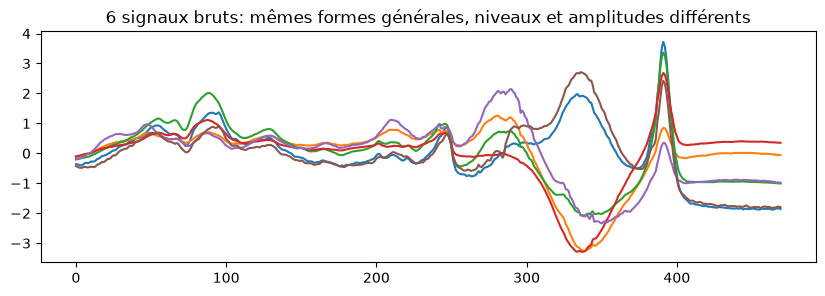

In [205]:
filename = "data/Beef_TRAIN.tsv"
data = pd.read_csv(filename, header=None, sep='\t')   # colonne 0 = étiquette, colonnes 1: = le signal

print("répartition des classes :", np.unique(data.values[:,0], return_counts=True))
print("dimensions              :", data.values[:,1:].shape, "(30 individus, 470 points de mesure)")

plt.figure(facecolor='white', figsize=[10,3])
plt.plot(data.values[:6,1:].T)
plt.title("6 signaux bruts: mêmes formes générales, niveaux et amplitudes différents")

In [206]:
from sklearn.preprocessing import MinMaxScaler

X = data.values[:,1:]
Y = data.values[:,0]
# remise en forme des Y entre 0 et nClasses-1
val    = np.unique(Y)
transf = dict(zip(val, np.arange(len(val))))
Y      = np.vectorize(transf.get)(Y)

mod = SVC()
sc  = cross_val_score(mod, X, Y, scoring='accuracy')
print("Scores bruts                 ", sc.round(3), "| moyenne : %.3f" % sc.mean())

# normalisation des données (par colonne, comportement par défaut de sklearn)
scal = MinMaxScaler()
#scal = StandardScaler()   # vous pouvez switcher pour voir...
Xn   = scal.fit_transform(X)
sc   = cross_val_score(mod, Xn, Y, scoring='accuracy')
print("Scores sur données normalisées", sc.round(3), "| moyenne : %.3f" % sc.mean())

Scores bruts                  [0.5   0.333 0.5   0.167 0.333] | moyenne : 0.367
Scores sur données normalisées [0.667 0.5   0.5   0.333 0.333] | moyenne : 0.467


#### <span style="color:red">Mini-exo</span> par ligne ou par colonne?

Sur ces signaux, les deux lectures sont défendables: chaque point de mesure peut être vu comme une
variable (donc normalisation par colonne), et chaque signal est un individu (donc normalisation par ligne).

1. Comparer les variantes: brut, min-max par colonne, standard par colonne, min-max par individu (attention
   à la transposition!), norme L1 et L2 par individu
2. Laquelle gagne? Et surtout: quelles sont celles qui **dégradent** la performance, et pourquoi?

In [207]:
# Comparer les 6 variantes demandées, à modèle (SVC) et validation croisée IDENTIQUES:
# le seul élément qui change d'une ligne à l'autre doit être la matrice passée à cross_val_score.
# Schéma de résolution: une liste de couples (nom, matrice transformée), puis une boucle d'affichage
#  - par colonne  : MinMaxScaler() / StandardScaler() s'appliquent directement à X
#  - par individu : MinMaxScaler().fit_transform(X.T).T   <- attention à la double transposition!
#                   Normalizer(norm='l1' / 'l2') travaille déjà ligne par ligne, sans transposition
#                   (from sklearn.preprocessing import Normalizer)
# => une dizaine de lignes

###  TODO  ###

Réponse:

 TODO 

<a id="sec-b"></a>
## B. Étude approfondie du cas Auto-MPG

Nous quittons les exemples jouets: il s'agit maintenant d'enchainer *tous* les outils de la partie A sur un
seul jeu de données réaliste, et de mesurer ce que chaque étape rapporte.

Le jeu de données UCI **Auto-MPG** consiste à prédire la consommation (`mpg`, *miles per gallon*) d'un
ensemble de voitures à partir de leurs caractéristiques.
[Description du jeu](https://archive.ics.uci.edu/ml/datasets/auto+mpg)

| # | colonne | nature | difficulté |
|---|---|---|---|
| — | `mpg` | continue | **la cible** |
| 0 | `cylinders` | entier, 5 valeurs | numérique *ou* catégorielle? |
| 1 | `displacement` | continue | cylindrée |
| 2 | `horsepower` | continue | **contient des `?`** — lue comme du texte par pandas |
| 3 | `weight` | continue | |
| 4 | `acceleration` | continue | |
| 5 | `model year` | entier, 13 valeurs | numérique *ou* catégorielle? |
| 6 | `origin` | entier, 3 valeurs | catégorielle déguisée en nombre |
| 7 | `car name` | **texte libre** | 305 valeurs distinctes pour 398 lignes |

Le programme de la partie:

1. régler le problème des données manquantes (B.1);
2. regarder ce que contiennent réellement les colonnes (B.2);
3. tester un régresseur de référence sur les seules colonnes numériques, puis encoder les colonnes
   catégorielles et mesurer le gain (B.3);
4. discrétiser une variable continue (B.4), puis fabriquer une variable *métier* (B.5);
5. vérifier si tout ce travail sert encore à un modèle de l'état de l'art (B.6).

Deux questions restent ouvertes tout du long, et on y répondra expérimentalement: **que faire des colonnes
de date et de cylindrée** (numérique *vs* catégoriel)? et **comment exploiter la colonne texte** (le nom
complet du modèle est inutilisable, la marque seule est peut-être informative)?

In [208]:
# Chargement des données (1/2)

filename = "data/auto-mpg.csv"
data = pd.read_csv(filename)
X = data.values[:,1:]   # 8 colonnes de description (la 8e est du texte -> X est de type "object")
Y = data.values[:,0]    # la cible: mpg

# La colonne 2 (horsepower) contient des données manquantes, notées '?'...
# Conséquence: pandas la lit comme une colonne de chaines de caractères.
print("types lus par pandas :\n", data.dtypes, "\n")
data.loc[30:40, :]      # équivalent pandas de print(X[30:40]) ; voir les '?' en horsepower

types lus par pandas :
 mpg             float64
cylinders         int64
displacement    float64
horsepower          str
weight            int64
acceleration    float64
model year        int64
origin            int64
car name            str
dtype: object 



,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
30,28.0,4,140.0,90,2264,15.5,71,1,chevrolet vega 2300
31,25.0,4,113.0,95,2228,14.0,71,3,toyota corona
32,25.0,4,98.0,?,2046,19.0,71,1,ford pinto
33,19.0,6,232.0,100,2634,13.0,71,1,amc gremlin
34,16.0,6,225.0,105,3439,15.5,71,1,plymouth satellite custom
35,17.0,6,250.0,100,3329,15.5,71,1,chevrolet chevelle malibu
36,19.0,6,250.0,88,3302,15.5,71,1,ford torino 500
37,18.0,6,232.0,100,3288,15.5,71,1,amc matador
38,14.0,8,350.0,165,4209,12.0,71,1,chevrolet impala
39,14.0,8,400.0,175,4464,11.5,71,1,pontiac catalina brougham


<a id="sec-b1"></a>
### B.1 La gestion des données manquantes

De nombreux jeux de données présentent des données manquantes, souvent dans une ou deux colonnes et sur
quelques lignes. La question de savoir comment les traiter occupe beaucoup la communauté.

1. Du point de vue théorique, cela relève de l'algorithme EM pour l'estimation des valeurs manquantes
2. Du point de vue très opérationnel, on peut:
    * supprimer les lignes affectées (simple, mais on jette des individus — ici 6 sur 398);
    * affecter la valeur moyenne (ou médiane) de la colonne aux cases manquantes (cf. cellule ci-dessous);
3. D'autres stratégies, plus fines, sont disponibles dans scikit-learn (cf. plus bas).

Commençons par le faire **à la main**, pour bien voir ce qui se passe.

In [209]:
# Chargement des données (2/2): remplacement des '?' par la moyenne de la colonne [A LA MAIN]

# 1. on repère les '?' et on les met provisoirement à 0 (au passage: conversion texte -> entier)
X[:,2] = [0 if X[i,2] == '?' else int(X[i,2]) for i in range(len(X))]
# 2. on calcule la moyenne des valeurs VALIDES (le dénominateur ne compte que les cases non nulles)
m = np.round(X[:,2].sum() / np.where(X[:,2]>0, 1, 0).sum())   # 104
# 3. on remplace les 0 par cette moyenne
X[:,2] = np.where(X[:,2]==0, m, X[:,2])

print("puissance moyenne utilisée pour l'imputation :", m)
print(X[30:40])     # la ligne 32, qui valait '?', vaut maintenant 104

puissance moyenne utilisée pour l'imputation : 104.0
[[4 140.0 90 2264 15.5 71 1 'chevrolet vega 2300']
 [4 113.0 95 2228 14.0 71 3 'toyota corona']
 [4 98.0 104.0 2046 19.0 71 1 'ford pinto']
 [6 232.0 100 2634 13.0 71 1 'amc gremlin']
 [6 225.0 105 3439 15.5 71 1 'plymouth satellite custom']
 [6 250.0 100 3329 15.5 71 1 'chevrolet chevelle malibu']
 [6 250.0 88 3302 15.5 71 1 'ford torino 500']
 [6 232.0 100 3288 15.5 71 1 'amc matador']
 [8 350.0 165 4209 12.0 71 1 'chevrolet impala']
 [8 400.0 175 4464 11.5 71 1 'pontiac catalina brougham']]


<span style="color:blue">*Ce bricolage fonctionne, mais il est fragile*</span> (il suppose qu'aucune valeur valide ne vaut 0) et surtout il
n'est pas *réutilisable*: la moyenne calculée ici n'est stockée nulle part, impossible de l'appliquer
demain à de nouvelles voitures.

Les stratégies alternatives de scikit-learn, **à maitriser** :
[module `sklearn.impute`](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.impute)

In [210]:
# Application directe de la fonction... et premier échec instructif
from sklearn.impute import SimpleImputer

filename = "data/auto-mpg.csv"
data = pd.read_csv(filename, na_values='?')   # => les '?' deviennent des NaN
                                              #    et horsepower est enfin lue comme une colonne numérique
Xall = data.values[:,1:]
Y    = data.values[:,0]

imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
try:
    Xnum = imp_mean.fit_transform(Xall)
except ValueError as e:
    print("ECHEC :", e)

# Que s'est-il passé? Ce n'est PAS le '?' (na_values l'a réglé), c'est la dernière colonne,
# 'car name', qui contient du texte: une moyenne n'a aucun sens dessus.

ECHEC : Cannot use mean strategy with non-numeric data:
could not convert string to float: 'chevrolet chevelle malibu'


In [211]:
# Version corrigée: on restreint l'imputation aux colonnes numériques
# colonnes 1 à 6 du fichier = cylinders, displacement, horsepower, weight, acceleration, model year
Xnum = data.values[:,1:7].astype(float)

print("nombre de NaN avant :", np.isnan(Xnum).sum())
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
Xnum = imp_mean.fit_transform(Xnum)
print("nombre de NaN après :", np.isnan(Xnum).sum())
print("valeur apprise pour l'imputation :", imp_mean.statistics_[2].round(2))   # comparer avec le m ci-dessus

print(Xnum[30:40])

nombre de NaN avant : 6
nombre de NaN après : 0
valeur apprise pour l'imputation : 104.47
[[4.00000000e+00 1.40000000e+02 9.00000000e+01 2.26400000e+03
  1.55000000e+01 7.10000000e+01]
 [4.00000000e+00 1.13000000e+02 9.50000000e+01 2.22800000e+03
  1.40000000e+01 7.10000000e+01]
 [4.00000000e+00 9.80000000e+01 1.04469388e+02 2.04600000e+03
  1.90000000e+01 7.10000000e+01]
 [6.00000000e+00 2.32000000e+02 1.00000000e+02 2.63400000e+03
  1.30000000e+01 7.10000000e+01]
 [6.00000000e+00 2.25000000e+02 1.05000000e+02 3.43900000e+03
  1.55000000e+01 7.10000000e+01]
 [6.00000000e+00 2.50000000e+02 1.00000000e+02 3.32900000e+03
  1.55000000e+01 7.10000000e+01]
 [6.00000000e+00 2.50000000e+02 8.80000000e+01 3.30200000e+03
  1.55000000e+01 7.10000000e+01]
 [6.00000000e+00 2.32000000e+02 1.00000000e+02 3.28800000e+03
  1.55000000e+01 7.10000000e+01]
 [8.00000000e+00 3.50000000e+02 1.65000000e+02 4.20900000e+03
  1.20000000e+01 7.10000000e+01]
 [8.00000000e+00 4.00000000e+02 1.75000000e+02 4.464000

**À retenir**: `imp_mean` a *appris* (`fit`) une valeur de remplacement et sait l'*appliquer* (`transform`)
à n'importe quelle nouvelle matrice. C'est cette propriété — et pas le gain de deux lignes de code — qui
justifie d'abandonner le bricolage manuel. On la retrouvera pour tous les pré-traitements de la partie C.

À noter aussi que `strategy='median'` est souvent préférable à `'mean'` en présence de valeurs extrêmes, et
que `strategy='constant'` accompagné d'une colonne indicatrice (`add_indicator=True`) permet de dire au
modèle *que* la valeur était manquante — ce qui est parfois une information en soi.

<a id="sec-b2"></a>
### B.2 Analyse du contenu des colonnes

Avant de modéliser, on regarde. Nous nous intéressons d'abord à la dernière colonne, qui est la plus
problématique (elle n'est pas numérique)... puis à toutes les autres.

In [212]:
# Analyse de la dernière colonne (car name)
print("Combien de valeurs uniques :", len(np.unique(X[:,-1])), " (pour", len(X), "lignes)")
print(X[:5,-1])

# => presque autant de modalités que de lignes: un encodage one-hot direct produirait une matrice
#    quasi-diagonale, dont aucun modèle ne pourrait rien tirer (une colonne = une seule voiture).

Combien de valeurs uniques : 305  (pour 398 lignes)
['chevrolet chevelle malibu' 'buick skylark 320' 'plymouth satellite'
 'amc rebel sst' 'ford torino']


In [213]:
# Il faut donc réduire la cardinalité: on se limite à la marque.
# (le premier mot du nom; cette information peut avoir de la valeur pour estimer la consommation)
# Ecraser la colonne X[:,-1] par le premier mot de chaque nom (méthode .split() des chaines de
# caractères, dans une compréhension de liste), puis vérifier combien de modalités il reste => 2-3 lignes

X[:,-1] = [k.split()[0] for k in X[:,-1]]
print("Combien de valeurs uniques :", len(np.unique(X[:,-1])), " (pour", len(X), "lignes)")


Combien de valeurs uniques : 37  (pour 398 lignes)


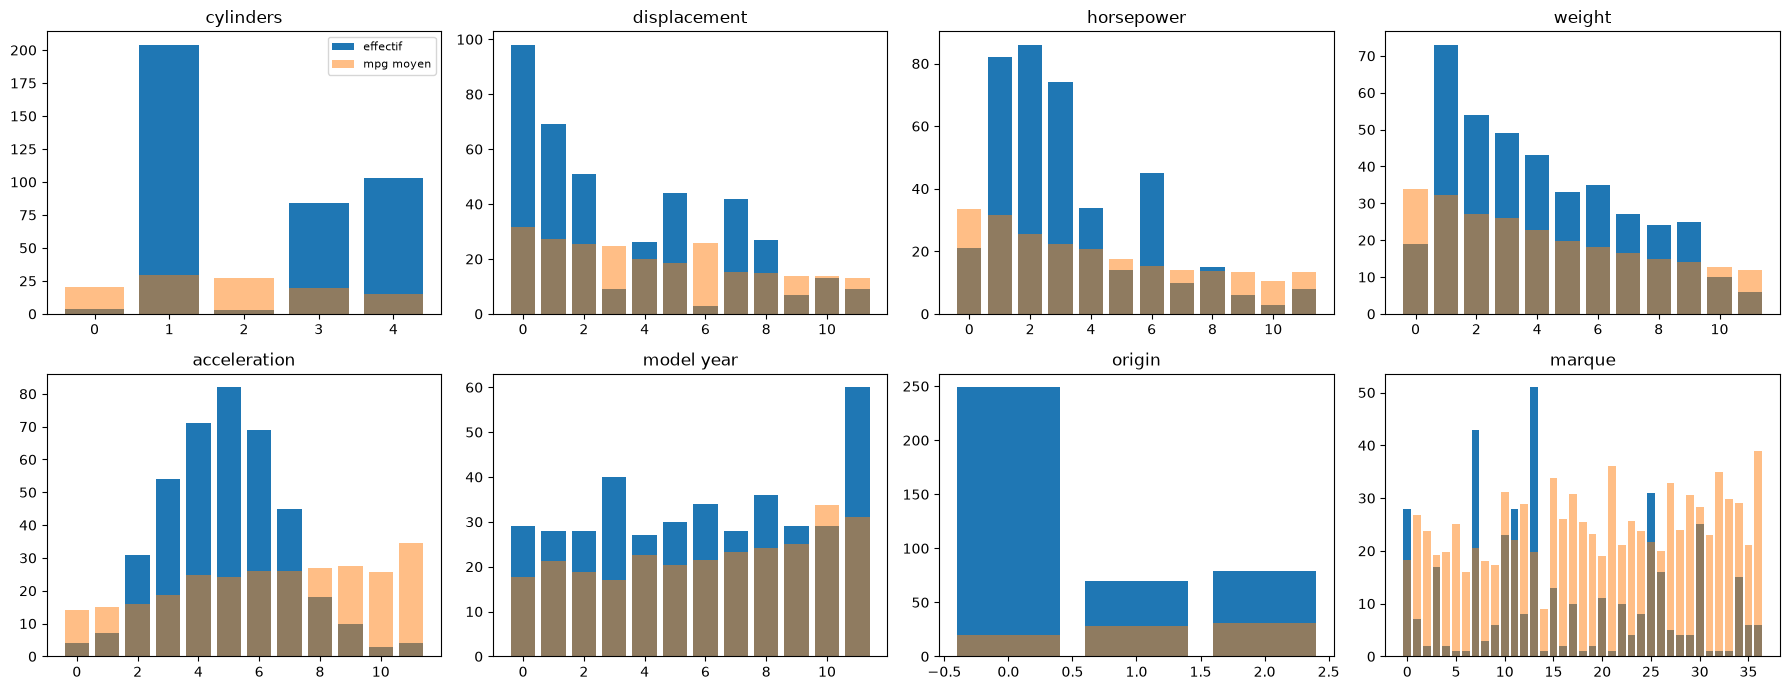

In [214]:
# Analyse de toutes les colonnes: effectifs (bleu) et consommation moyenne par tranche (orange)
ncol = X.shape[1]
plt.figure(facecolor='white', figsize=[18,7])
for i in range(ncol):
    plt.subplot(2, (ncol+1)//2, i+1)
    if i < ncol-1:                                       # colonnes numériques
        nbins  = np.minimum(len(np.unique(X[:,i])), 12)  # peu de bins si la colonne est déjà discrète
        [e, x] = np.histogram(X[:,i], nbins)
        x[-1] += 0.001                                   # pour inclure la borne max dans la dernière tranche
        conso  = [Y[np.logical_and(X[:,i]>=x[j], X[:,i]<x[j+1])].mean() for j in range(len(e))]
    else:                                                # colonne textuelle (la marque)
        val, e = np.unique(X[:,-1], return_counts=True)
        conso  = [Y[X[:,-1] == v].mean() for v in val]
    plt.bar(np.arange(len(e)), e,     label='effectif')
    plt.bar(np.arange(len(e)), conso, label='mpg moyen', alpha=0.5)
    plt.title(data.columns[i+1] if i < ncol-1 else "marque")
    if i == 0: plt.legend(fontsize=8)
plt.tight_layout()
#plt.savefig('fig/auto-mpg-all.png')
plt.show()

# Ce qu'on cherche sur ces figures: une barre orange qui VARIE d'une tranche à l'autre signale une
# colonne informative. Regarder en particulier 'model year' (variation nette et monotone) et 'origin'.

<a id="sec-b3"></a>
### B.3 Performance de référence, puis enrichissement

On calcule d'abord une performance sur les seules colonnes numériques, faciles à exploiter... puis on
enrichit la représentation, colonne catégorielle par colonne catégorielle, en mesurant le gain à chaque
étape.

La métrique retenue est l'**erreur relative moyenne** (MAPE, *mean absolute percentage error*): scikit-learn
maximisant toujours son critère, on utilise son opposé `neg_mean_absolute_percentage_error`. Un score de
$-0.15$ se lit donc "15% d'erreur relative en moyenne", et **plus c'est proche de 0, mieux c'est**.

In [215]:
from sklearn.linear_model import Ridge

# Modèle de référence sur les colonnes purement numériques
# Xnum = [cylinders, displacement, horsepower, weight, acceleration, model year]
# On retire la colonne 0 (cylinders): elle ne prend que 5 valeurs, on la traitera en catégoriel ci-dessous.
Xr  = Xnum[:,1:6]
mod = Ridge()

sc = cross_val_score(mod, Xr, Y, scoring='neg_mean_absolute_percentage_error')
print("modèle de référence :", sc.round(3), "| moyenne : %.4f" % sc.mean(), "| dimensions :", Xr.shape)

modèle de référence : [-0.203 -0.166 -0.099 -0.138 -0.129] | moyenne : -0.1471 | dimensions : (398, 5)


In [219]:
# Transformation des données et amélioration (?) des résultats
# Pour chacune des colonnes discrètes, on construit son encodage one-hot et on le concatène à Xr.
# ATTENTION: Xr grossit à chaque tour de boucle -> ne pas relancer la cellule deux fois de suite!

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
noms_col = {0: 'cylinders', 5: 'model year', 6: 'origin', 7: 'marque'}
Xr_bis = np.copy(Xr)

for col in [0, 5, 6, 7]:
    Xtmp = enc.fit_transform(X[:, col].reshape(-1, 1))

    Xr_bis = np.concatenate((Xr_bis, Xtmp), axis=1)

    sc = cross_val_score(
        mod, Xr_bis, Y,
        scoring='neg_mean_absolute_percentage_error'
    )

    print(
        "+ %-10s : %d colonnes, dimension %s, score %.4f"
        % (noms_col[col], Xtmp.shape[1], Xr_bis.shape, sc.mean())
    )

Xr = Xr_bis

+ cylinders  : 5 colonnes, dimension (398, 15), score -0.1248
+ model year : 13 colonnes, dimension (398, 28), score -0.1201
+ origin     : 3 colonnes, dimension (398, 31), score -0.1199
+ marque     : 37 colonnes, dimension (398, 68), score -0.1181


Lecture des résultats:

 TODO 

<a id="sec-b4"></a>
### B.4 Discrétisation d'une variable continue

Application directe de [A.1.3](#sec-a13). Sur la colonne 1 (`displacement`, la cylindrée), l'histogramme de
B.2 laissait penser que les comportements étaient similaires par *groupes* de valeurs plutôt que
proportionnels à la cylindrée. On convertit donc cette variable continue en tranches.

In [220]:
# Discrétisation de la caractéristique 1 (displacement / cylindrée)
from sklearn.preprocessing import KBinsDiscretizer

dim = 1   # dimension à encoder ; 5 pour tester sur 'model year'
#print(X[:10,dim])

# n_bins = nombre de tranches ; encode='onehot' = une colonne binaire par tranche (sortie creuse)
# strategy='uniform' = tranches de même largeur (vs 'quantile' = tranches de même effectif)
enc  = KBinsDiscretizer(n_bins=4, encode='onehot', strategy='uniform')
Xtmp = enc.fit_transform(X[:,dim].reshape(-1,1)).toarray()
#print(Xtmp[:10,:])

Xr = np.concatenate((Xr, Xtmp), axis=1)
sc = cross_val_score(mod, Xr, Y, scoring='neg_mean_absolute_percentage_error')
print("bornes des tranches :", enc.bin_edges_[0].round(1))
print("+ %d colonnes -> %d : %.4f" % (Xtmp.shape[1], Xr.shape[1], sc.mean()))
# => -0.1228 -> -0.1178 : la variable continue était bien mieux exploitée par morceaux

bornes des tranches : [ 68.  164.8 261.5 358.2 455. ]
+ 4 colonnes -> 72 : -0.1180


<a id="sec-b5"></a>
### B.5 Transformations arbitraires (métier)

Rien n'oblige à se limiter aux transformations du catalogue: la connaissance du domaine permet de fabriquer
des variables qu'aucun outil générique ne trouverait.

**Exercice**: enrichir les données en construisant une colonne binaire qui vaut 1 pour les voitures de 4
cylindres de moins de 2500 (livres) en masse — la catégorie des petites citadines économiques.

In [221]:
# Créer une colonne binaire qui recense les petites voitures (masse < 2500) de 4 cylindres
# rappel des indices de X : 0=cylinders, 1=displacement, 2=horsepower, 3=weight, 4=acceleration, ...
# np.where(np.logical_and(cond1, cond2), 1, 0) donne un vecteur: .reshape(-1,1) pour en faire une colonne
# puis, comme dans la cellule précédente: concaténation à Xr et réévaluation => 3 à 4 lignes
# (contrôle utile avant d'aller plus loin: combien de voitures sont concernées? si c'est 0 ou 398,
#  la variable ne pourra rien apporter)

###  TODO  ###
A = X[:,0]==4
B = X[:,3]<2500
Xtmp = np.where((X[:,0]==4) + (X[:,3]<2500),1,0).reshape(-1,1)

Xr = np.hstack((Xr,Xtmp))
print(Xr.shape)

(398, 73)


<a id="sec-b6"></a>
### B.6 Passage à un modèle de l'état de l'art

Bilan de la partie B: nous sommes passés de 14.7% à 11.4% d'erreur relative avec une simple régression
Ridge, uniquement en retravaillant la représentation.

Question naturelle: est-ce que les variables construites ont encore du sens pour un modèle non linéaire de
type XGBoost, qui est réputé savoir se débrouiller seul?

In [222]:
# Passage à un modèle de l'état de l'art : XGBoost
import xgboost as xgb   # !pip install xgboost # en cas de besoin

bst = xgb.XGBRegressor()

sc = cross_val_score(bst, Xr, Y, scoring='neg_mean_absolute_percentage_error')
print("xgboost (représentation enrichie) : %.4f" % sc.mean())

sc = cross_val_score(bst, X[:,:6], Y, scoring='neg_mean_absolute_percentage_error')
print("xgboost (6 colonnes d'origine)    : %.4f" % sc.mean())

xgboost (représentation enrichie) : -0.1037
xgboost (6 colonnes d'origine)    : -0.1051


Lecture des résultats:

 TODO 

<a id="sec-c"></a>
## C. Construire une chaine de traitements en scikit-learn

La partie B a fonctionné, mais elle a laissé derrière elle une dizaine de variables intermédiaires
(`X`, `Xall`, `Xnum`, `Xr`, `Xtmp`...), une boucle qu'il ne faut surtout pas relancer deux fois, et une
préparation des données qu'il serait impossible d'appliquer telle quelle à une nouvelle voiture.

Scikit-learn propose un objet qui règle les trois problèmes d'un coup: le
[`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html). Il chaine
des transformations (qui ont un `fit` et un `transform`) et termine par un estimateur (qui a un `fit` et un
`predict`) — le tout se comportant **exactement comme un estimateur unique**.

Trois bénéfices, dans l'ordre d'importance:

1. **la correction méthodologique**: lors d'une validation croisée, `fit` n'est appelé que sur les données
   d'apprentissage de chaque pli. La fuite de données décrite en B.3 devient structurellement impossible;
2. **la reproductibilité**: un seul objet contient toute la recette, il se sérialise et s'applique à de
   nouvelles données;
3. **l'optimisation de bout en bout**: les paramètres des pré-traitements deviennent des hyper-paramètres
   comme les autres, réglables par `GridSearchCV` ou Optuna (C.3 et C.4).

<a id="sec-c1"></a>
### C.1 Une première chaine: sélection de caractéristiques + SVM

1. Construire des données bruitées (2 dimensions utiles + 20 dimensions de bruit, comme dans le TP
   précédent)
2. Construire un sélecteur de variables pertinentes
    * pour prolonger le TP précédent, on choisit un sélecteur basé sur la corrélation... en utilisant
      l'**héritage** pour une parfaite intégration dans la chaine
3. L'intégrer dans une chaine (`Pipeline`)
4. Vérifier:
    * que la chaine est apprenable
    * qu'elle est évaluable
    * que les éléments de la chaine ont des dimensions raisonnables

In [ ]:
# Données jouets: 2 dimensions utiles + 20 dimensions inutiles
np.random.seed(0)                       # pour que le bruit soit reproductible d'une exécution à l'autre
centers      = [[-2.0, -2.0], [2.0, 2.0]]
clusters_std = [1.5, 1.5]
X, y = make_blobs(n_samples=100, centers=centers, cluster_std=clusters_std,
                  n_features=2, random_state=0)          # 100 points, 2 classes, 2 dimensions

# ajout de bruit pur (aucune information sur y)
ndim_noise = 20
Noise = np.random.randn(len(X), ndim_noise)*clusters_std[0]
Xn    = np.concatenate((X, Noise), axis=1)

# split
X_train, X_test, y_train, y_test = train_test_split(Xn, y, test_size=0.33, random_state=0)
print("apprentissage :", X_train.shape, "| test :", X_test.shape)

In [ ]:
# Un estimateur "maison", qui note un sous-ensemble de variables par sa liaison avec la cible.
# Hériter de BaseEstimator suffit à le rendre utilisable partout dans scikit-learn
# (get_params / set_params / clone sont fournis par la classe mère).
#  => fit ne fait rien: il n'y a rien à apprendre, le score est un calcul direct
#  => score renvoie la somme des liaisons |X_j . y| des variables retenues
from sklearn.base import BaseEstimator

class Correl(BaseEstimator):
    def fit(self, X, y):
        return self                                  # aucun paramètre à estimer
    def score(self, X, y):
        # y est dans {0,1} : on le recentre dans {-1,+1}, sinon le produit scalaire ne somme
        # que les exemples de la classe 1 (cf. la discussion du TP précédent sur les filtres)
        # la valeur absolue garantit qu'une liaison négative compte autant qu'une liaison positive
        return np.sum(np.abs(X.T @ (2*y - 1)))

In [ ]:
# Sélection de caractéristiques: mon critère maison, branché dans le sélecteur générique de sklearn
from sklearn.feature_selection import SequentialFeatureSelector

estimator = Correl()
selector  = SequentialFeatureSelector(estimator, n_features_to_select=4)
selector  = selector.fit(X_train, y_train)

print("variables retenues :", np.where(selector.get_support())[0])   # 0 et 1 sont bien dedans

# il est ensuite possible de filtrer les données:
Xnew = selector.transform(X_train)
print("dimensions après sélection :", X_train.shape, "->", Xnew.shape)

In [ ]:
# Construction de la chaine (pipeline)
from sklearn.pipeline import Pipeline

classif = svm.SVC(kernel='linear')
# liste de tuples: (titre, objet). Le titre servira à désigner les hyper-paramètres en C.3
pipe = Pipeline([('sel. var', selector), ('classif', classif)])
pipe

In [ ]:
# Vérification de l'usage et des propriétés du nouvel objet:
# il s'utilise EXACTEMENT comme un classifieur ordinaire
pipe.fit(X_train, y_train)          # 1. apprentissage: fit du sélecteur PUIS fit du classifieur
yhat = pipe.predict(X_test)         # 2. inférence   : transform du sélecteur PUIS predict du classifieur
tx   = accuracy_score(yhat, y_test) # 3. évaluation

print("taux de bonne classif : ", tx)

In [ ]:
# Vérification des dimensions du classifieur: il n'a vu que les 4 variables sélectionnées,
# et pas les 22 de départ. La réduction a bien eu lieu À L'INTÉRIEUR de la chaine.
print("Dimension du classifieur : ", classif.coef_.shape)

<a id="sec-c2"></a>
### C.2 Deuxième chaine: ACP + arbre de décision

**Exercice**: construire une chaine composée de

* une projection PCA sur 3 axes
* un arbre de décision

Calculer la performance de cette chaine et afficher l'arbre. On notera que le code de la chaine est
identique au précédent: seuls les deux objets changent.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Le code est le MÊME que celui de la chaine de C.1: seuls les deux objets changent.
# 1. instancier PCA(n_components=3) et DecisionTreeClassifier(random_state=0)
# 2. les assembler: Pipeline([('sel. var', ...), ('classif', ...)])
# 3. fit sur (X_train, y_train), predict sur X_test, puis accuracy_score
# 4. trois affichages qui serviront au commentaire demandé juste après:
#    - selvar.explained_variance_ratio_ : la part de variance captée par chacun des 3 axes
#      (repère: avec 22 dimensions, un axe de pur bruit tourne autour de 1/22 = 4.5%)
#    - classif.feature_importances_     : les axes réellement utilisés par l'arbre
#    - plot_tree(classif, filled=True)  : le dessin de l'arbre, dans une figure de taille [10,10]

###  TODO  ###

Commentaire:

 TODO 

In [ ]:
# Vérifier la fragilité annoncée ci-dessus: on ne change QUE la dispersion du bruit ajouté,
# l'information utile (les deux gaussiennes de make_blobs) ne bouge pas d'un iota.
# Schéma de résolution: une boucle sur std_noise in [1.5, 3.0, 5.0] qui, à chaque tour,
#  1. régénère les données comme plus haut: make_blobs(...) puis concaténation de
#     np.random.randn(len(Xb), ndim_noise) * std_noise
#  2. redécoupe en apprentissage / test (train_test_split)
#  3. réapprend la chaine PCA(3) + arbre, et affiche sur une ligne: l'accuracy,
#     explained_variance_ratio_ et feature_importances_
# Comparer ensuite les 3 lignes obtenues: l'ACP retient-elle toujours la direction utile?

###  TODO  ###

Lecture du tableau obtenu (que deviennent la variance expliquée par chaque axe et les importances
dans l'arbre quand le bruit se disperse?):

 TODO 

<a id="sec-c3"></a>
### C.3 Optimiser la chaine avec `GridSearchCV`

La construction n'est pas une fin en soi: l'idée est de pouvoir optimiser la chaine à la fois au niveau des
paramètres de pré-traitement et des hyper-paramètres du modèle. **Les deux ensemble**, puisque nous avons
vu en [B.6](#sec-b6) qu'ils ne sont pas indépendants.

La syntaxe est celle du double *underscore*: `nomDuMaillon__nomDuParametre`.

On veut tester les options suivantes (en combinaison):

* sélection de 2 à 5 variables (avec le sélecteur simple à base de corrélation)
* SVM
    * noyau linéaire
    * noyau gaussien avec `gamma = [0.1, 0.5, 1, 2, 5]`
    * compromis de régularisation : `C = [0.1, 1, 5, 10, 100]`

1. Construire la chaine de traitement
2. Utiliser le `grid_search` vu dans le TP 1 pour optimiser l'ensemble
    * dans un premier temps, mettre tous les paramètres *en vrac* — <BR>
      https://scikit-learn.org/stable/tutorial/statistical_inference/putting_together.html
    * dans un second temps, essayer de ne pas calculer les combinaisons absurdes (tester toutes les valeurs
      de `gamma` pour un noyau linéaire, qui n'en utilise aucune) <BR>
      Il faut passer une **liste de dictionnaires**: chaque dictionnaire décrit une grille indépendante, et
      les combinaisons ne sont calculées qu'à l'intérieur de chacune.
3. Expliquer quelle chaine est retenue, et à quel niveau de performance attendu

> À votre avis, êtes-vous dans un cadre APP/TEST ou dans un cadre APP/VAL/TEST? (la réponse complète est
> en [D.6](#sec-d6))

In [ ]:
# Construction de la chaine (pipeline)
import time
from sklearn.model_selection import GridSearchCV, ParameterGrid

### MISE EN PLACE DE LA CHAINE ###
classif = svm.SVC()
# liste de tuples: titre + objet ; le titre préfixe les hyper-paramètres ci-dessous
pipe = Pipeline([('selvar', selector), ('classif', classif)])

# V1 : tous les paramètres en vrac, sous la forme TITRE__parametre: [valeurs à tester]
grid_v1 = {
    "selvar__n_features_to_select": [2, 3, 4, 5],
    "classif__C":      [0.1, 1, 5, 10, 100],
    "classif__gamma":  [0.1, 0.5, 1, 2, 5],
    "classif__kernel": ["linear", "rbf"],
}

# V2 : une liste de dictionnaires = plusieurs grilles indépendantes.
#      gamma n'est exploré QUE pour le noyau gaussien, qui est le seul à s'en servir.
grid_v2 = grid_v1    # TODO : remplacer par une LISTE de dictionnaires (un par noyau)

###  TODO  ###

print("nombre de combinaisons: V1 =", len(list(ParameterGrid(grid_v1))),
      "| V2 =", len(list(ParameterGrid(grid_v2))))

for nom, grid in [("V1 (en vrac)", grid_v1), ("V2 (grilles séparées)", grid_v2)]:
    t0     = time.time()
    search = GridSearchCV(pipe, grid, n_jobs=2)
    search.fit(X_train, y_train)
    print("%-22s %5.1f s | CV score = %0.3f | %s"
          % (nom, time.time()-t0, search.best_score_, search.best_params_))

Lecture des résultats:

 TODO 

<a id="sec-c4"></a>
### C.4 Optimiser la chaine avec Optuna

`GridSearchCV` a un défaut rédhibitoire: son coût est le **produit** du nombre de valeurs testées. Ajouter
un troisième hyper-paramètre à 5 valeurs multiplie le temps par 5, et la grille impose de fixer à l'avance
les valeurs candidates.

[Optuna](https://optuna.readthedocs.io/en/stable/) propose des outils plus avancés:

1. des outils agréables pour le *grid-search*;
2. surtout, le passage du *grid-search* à une **optimisation guidée** qui brise la combinatoire: chaque
   essai est choisi en fonction des résultats des essais précédents (optimisation bayésienne), et les
   branches non prometteuses sont abandonnées en cours de route.

Les trois étapes ci-dessous sont reprises du tutoriel officiel, qui me semble parfait
(source: https://optuna.readthedocs.io/en/stable/).

In [ ]:
# Si besoin
# ! pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # sinon 100 lignes de log par étude

<a id="sec-c41"></a>
#### C.4.1 Le problème d'optimisation, sans optimisation

On part d'une fonction objectif qui ne prend aucun argument: le modèle est entièrement figé, on se contente
de mesurer sa performance. C'est le point de départ à améliorer.

In [ ]:
import sklearn.datasets
import sklearn.ensemble
import sklearn.model_selection


def objective():
    iris = sklearn.datasets.load_iris()   # Prepare the data.

    clf = sklearn.ensemble.RandomForestClassifier(n_estimators=5, max_depth=3)  # Define the model.

    return sklearn.model_selection.cross_val_score(
        clf, iris.data, iris.target, n_jobs=-1, cv=3
    ).mean()   # Train and evaluate the model.


print("Accuracy: {}".format(objective()))

<a id="sec-c42"></a>
#### C.4.2 Une recherche qui brise la combinatoire

On laisse maintenant Optuna se *balader* dans l'espace des paramètres.

1. Remplacer les valeurs figées des paramètres par un générateur, et faire prendre à l'objectif un argument
   `trial`:
```
n_estimators = trial.suggest_int("n_estimators", 2, 20)
```
2. Lancer l'optimisation:
```
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)
```

Noter la différence de nature avec `GridSearchCV`: on ne donne plus une *liste de valeurs* mais un
**intervalle**, et c'est le nombre d'essais (`n_trials`) qui fixe le budget — indépendamment du nombre
d'hyper-paramètres.

In [ ]:
def objective(trial):
    iris = sklearn.datasets.load_iris()

    # suggest_int / suggest_float : des intervalles, pas des listes de valeurs
    n_estimators = trial.suggest_int("n_estimators", 2, 20)
    max_depth    = int(trial.suggest_float("max_depth", 1, 32, log=True))   # log=True : échelle log

    clf = sklearn.ensemble.RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth)

    return sklearn.model_selection.cross_val_score(
        clf, iris.data, iris.target, n_jobs=-1, cv=3
    ).mean()


study = optuna.create_study(direction="maximize")   # maximize: notre objectif est une accuracy
study.optimize(objective, n_trials=100)

trial = study.best_trial

print("Accuracy: {}".format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

<a id="sec-c43"></a>
#### C.4.3 Hyper-paramètres conditionnels au modèle

C'est ici qu'Optuna dépasse vraiment `GridSearchCV`: la structure de l'espace de recherche est décrite par
du **code Python ordinaire**, donc un simple `if` suffit à ne proposer `gamma` que pour un SVC et
`n_estimators` que pour une forêt aléatoire. C'est la version élégante des "sous-dictionnaires" bricolés
en [C.3](#sec-c3) — et elle passe à l'échelle sur des espaces bien plus complexes.

In [ ]:
import sklearn.svm


def objective(trial):
    iris = sklearn.datasets.load_iris()

    # 1er tirage: quel modèle? les tirages suivants en dépendent
    classifier = trial.suggest_categorical("classifier", ["RandomForest", "SVC"])

    if classifier == "RandomForest":
        n_estimators = trial.suggest_int("n_estimators", 2, 20)
        max_depth    = int(trial.suggest_float("max_depth", 1, 32, log=True))

        clf = sklearn.ensemble.RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth
        )
    else:
        c = trial.suggest_float("svc_c", 1e-10, 1e10, log=True)

        clf = sklearn.svm.SVC(C=c, gamma="auto")

    return sklearn.model_selection.cross_val_score(
        clf, iris.data, iris.target, n_jobs=-1, cv=3
    ).mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

trial = study.best_trial

print("Accuracy: {}".format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

<a id="sec-c5"></a>
### C.5 Exercice: chaine complète sur les vins

Mêmes opérations que précédemment, mais:

* sur les données de qualité du vin
* avec une normalisation standard (cf. [A.2](#sec-a2))
* et une forêt aléatoire ou un XGBoost dont on fera varier le nombre et la profondeur des arbres

Prévoir la réponse **avant** de lancer: la normalisation va-t-elle servir à quelque chose ici?

In [ ]:
filename = "data/winequality-red.csv"
data = pd.read_csv(filename)
X = data.values[:,:-1]
Y = data.values[:,-1]
# remise en forme des Y entre 0 et nClasses-1
val    = np.unique(Y)
transf = dict(zip(val, np.arange(len(val))))   # mapping [3,...,8] => [0,...,5]
y      = np.vectorize(transf.get)(Y)           # application de la transformation

print(X.shape, "| classes :", np.unique(y, return_counts=True))

In [ ]:
# TODO : construire la chaine [StandardScaler -> RandomForest] et l'optimiser par GridSearchCV
# Schéma de résolution: c'est celui de C.3, seuls les objets de la chaine changent
#  1. Pipeline([('scaler', StandardScaler()), ('classif', RandomForestClassifier(random_state=0))])
#  2. une grille sur classif__n_estimators (nombre d'arbres) et classif__max_depth (profondeur,
#     avec None = illimitée dans la liste des valeurs testées)
#  3. GridSearchCV(pipe, grid, n_jobs=-1).fit(X, y), puis affichage de best_score_ et best_params_
#  4. refaire la même chose avec xgb.XGBClassifier() à la place de la forêt
#  5. le contrôle qui répond à la question posée: relancer la forêt SANS le StandardScaler (cf. A.2)

###  TODO  ###

Réponse:

 TODO 

<a id="sec-c6"></a>
### C.6 Colonnes hétérogènes: `ColumnTransformer`

Dernier maillon manquant. Jusqu'ici, une chaine appliquait le **même** traitement à toutes les colonnes.
Or la partie B a montré que le cas réaliste est l'inverse: normaliser les colonnes continues, encoder en
one-hot les colonnes catégorielles, discrétiser celles qui s'y prêtent — chacune son traitement, puis tout
recoller.

L'objet qui fait cela est le
[`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html):
on lui donne une liste de triplets `(nom, transformation, colonnes)` et il concatène les résultats.

* la chaine transformera certaines variables en catégories (one-hot)
* et appliquera une régression logistique

Le but est ensuite d'optimiser une chaine de traitement contenant de l'**enrichissement** de données — par
exemple en testant différentes valeurs pour le nombre de tranches de la discrétisation.

**Attention au paramètre `remainder`**: par défaut il vaut `'drop'`, donc *toute colonne non citée est
silencieusement supprimée*. C'est la source d'erreur numéro un avec cet objet.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Première version, volontairement minimale: on ne traite que 3 colonnes sur 11
features_id = [3]      # residual sugar -> découpée en tranches
scale_id    = [1, 2]   # volatile acidity, citric acid -> simplement centrées-réduites

preprocessor = ColumnTransformer(
    [
        ("mise_a_l_echelle", StandardScaler(), scale_id),
        (
            "tobin",
            KBinsDiscretizer(n_bins=10, encode='onehot', strategy='uniform'),
            features_id,
        ),
    ],
    # remainder='drop' par défaut : les 8 autres colonnes sont JETÉES
)

print("colonnes en entrée :", X.shape[1])
print("colonnes en sortie :", preprocessor.fit_transform(X).shape[1], "(2 mises à l'échelle + 10 tranches)")

log_reg = make_pipeline(preprocessor, LogisticRegression(max_iter=1000))
print("accuracy avec 3 colonnes sur 11 : %.4f" % cross_val_score(log_reg, X, y).mean())

In [ ]:
# Version complète: on garde TOUTES les colonnes, et on optimise le nombre de tranches
#  1. reprendre le ColumnTransformer ci-dessus, mais en donnant au StandardScaler toutes les colonnes
#     qui ne sont pas discrétisées (liste d'indices à construire par compréhension, à partir de
#     range(X.shape[1]) et de features_id)
#  2. remesurer l'accuracy: passer de 3 à 11 colonnes rapporte-t-il quelque chose?
#  3. optimiser par GridSearchCV le nombre de tranches ET la régularisation de la régression logistique.
#     make_pipeline nomme les maillons d'après leur classe en minuscules, et on descend dans la chaine
#     avec le double underscore => "columntransformer__tobin__n_bins" et "logisticregression__C"
#     (astuce générale quand on doute d'un nom: log_reg.get_params().keys() les liste tous)
#  4. garder une référence à comparer: la même régression logistique sans aucune discrétisation
###  TODO  ###

Lecture des résultats:

 TODO 

In [ ]:
# Exemple de référence de la documentation scikit-learn: la chaine complète sur le Titanic.
# Colonnes numériques (imputation + normalisation) et colonnes catégorielles (one-hot) traitées
# séparément, puis sélection de variables, puis modèle. Tout tient dans un objet.
# NB: fetch_openml télécharge les données -> une connexion internet est nécessaire.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression

Xt, yt = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)

numeric_features     = ["age", "fare"]
numeric_transformer  = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
categorical_features = ["embarked", "pclass"]

preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ],
    verbose_feature_names_out=False,   # noms de colonnes lisibles en sortie
)
log_reg = make_pipeline(preprocessor, SelectKBest(k=7), LogisticRegression(max_iter=1000))

sc = cross_val_score(log_reg, Xt, yt)
print("titanic :", sc.round(3), "| moyenne : %.3f" % sc.mean())

# Noter que les colonnes sont désignées par leur NOM (l'entrée est un DataFrame),
# ce qui est infiniment plus robuste que les indices numériques manipulés en partie B.

<a id="sec-d"></a>
## D. Exercices complémentaires

Les exercices de cette partie sont indépendants les uns des autres (chacun recharge ses propres données) et
peuvent être traités dans le désordre, selon le temps disponible. Ils prolongent chacun un point précis des
parties A à C.

| Exercice | Notion travaillée | Prolonge |
|---|---|---|
| D.1 | `fit` sur l'apprentissage, `transform` sur le test: l'erreur qui fausse tout | A.1.1, C |
| D.2 | refaire toute la partie B en une seule chaine, et vérifier qu'on retrouve le même score | B |
| D.3 | variables catégorielles à haute cardinalité: regrouper, nettoyer ou encoder par la cible | B.3 |
| D.4 | transformer la **cible**, pas seulement les entrées | B.6 |
| D.5 | écrire son propre transformateur et l'insérer dans une chaine | C.1 |
| D.6 | ordre des plis et validation croisée imbriquée: que vaut le score annoncé? | C.3 |

<a id="sec-d1"></a>
### D.1 `fit` sur l'apprentissage, `transform` sur le test

C'est **l'erreur numéro un** des chaines de traitement écrites à la main, et elle est d'autant plus
dangereuse qu'elle ne produit pas toujours un message d'erreur.

La règle: un pré-traitement a des *paramètres* (les moyennes d'un `StandardScaler`, la liste des modalités
d'un `OneHotEncoder`, la valeur de remplacement d'un `SimpleImputer`). Ces paramètres s'estiment sur
l'apprentissage (`fit`) et s'appliquent tels quels au test (`transform`). Appeler `fit_transform` sur le
test, c'est en réestimer de nouveaux — donc appliquer une transformation *différente* aux deux jeux.

1. Sur Auto-MPG, extraire la marque et découper en apprentissage / test
2. Encoder la marque **correctement**: `fit` sur l'apprentissage, `transform` sur les deux
3. Encoder la marque **incorrectement**: un `fit_transform` de chaque côté. Que se passe-t-il?
4. Pourquoi ce cas précis est-il, paradoxalement, plutôt une bonne nouvelle? Imaginer la variante
   silencieuse de la même erreur
5. Réécrire le tout avec un `Pipeline` et vérifier que l'erreur devient impossible à commettre

In [ ]:
# Schéma de résolution (les numéros renvoient à l'énoncé ci-dessus):
# 1. une seule variable explicative ici, la marque: l'extraire de la colonne 'car name' du DataFrame,
#    la mettre en matrice (reshape(-1,1)) et découper avec train_test_split
# 2. la BONNE façon: UN encodeur, .fit() sur l'apprentissage puis .transform() des DEUX côtés
#    apprendre une Ridge dessus et mesurer mean_absolute_percentage_error(yte, ...) sur le test
# 3. la MAUVAISE façon: DEUX encodeurs indépendants, un fit_transform de chaque côté
#    afficher le nombre de modalités vues de part et d'autre (enc.categories_), puis tenter le predict
#    -> l'entourer d'un try / except ValueError pour pouvoir afficher le message et continuer la cellule
# 4. la question 4 se rédige dans la cellule de texte suivante
# 5. la version Pipeline([('enc', OneHotEncoder(...)), ('reg', Ridge())]): un seul fit, une seule
#    version des paramètres de l'encodeur, l'erreur n'est plus exprimable

###  TODO  ###

Réponse:

 TODO 

<a id="sec-d2"></a>
### D.2 Auto-MPG en une seule chaine

Reprendre **tout** le travail de la partie B et le réécrire comme un unique objet scikit-learn, en
désignant les colonnes par leur nom plutôt que par leur indice.

La chaine doit contenir:

* l'imputation de `horsepower`
* l'encodage one-hot de `cylinders`, `model year`, `origin` et de la marque
* la discrétisation de `displacement` en 4 tranches
* l'indicatrice "petite voiture" de [B.5](#sec-b5) — chercher du côté de `FunctionTransformer`
* et une `Ridge` pour finir

Puis:

1. vérifier qu'on retrouve bien le score de la partie B ($\approx -0.114$). Que conclure sur la fuite de
   données évoquée en [B.3](#sec-b3)?
2. optimiser d'un coup le nombre de tranches et la régularisation. Combien de lignes cela demande-t-il, et
   combien en aurait-il fallu avec le code de la partie B?

In [ ]:
# Objectif: UN seul objet sklearn qui refait tout le travail de la partie B, en désignant les
# colonnes par leur nom. On travaille donc sur le DataFrame, pas sur un tableau numpy.
#  1. charger auto-mpg.csv (na_values='?'), ajouter une colonne 'marque', isoler la cible mpg
#     puis retirer 'mpg' et 'car name' des entrées
#  2. un ColumnTransformer à 4 maillons, chacun avec sa propre liste de colonnes:
#     - SimpleImputer(strategy='mean')                  sur les colonnes numériques (horsepower a des trous)
#     - OneHotEncoder(handle_unknown='ignore', ...)     sur les colonnes catégorielles
#     - KBinsDiscretizer(n_bins=4, encode='onehot-dense') sur ['displacement']
#     - FunctionTransformer(f)                          sur ['cylinders','weight'] pour l'indicatrice
#       "petite voiture" de B.5; f reçoit le sous-DataFrame et doit RENVOYER UNE MATRICE (reshape(-1,1))
#     NB: une même colonne peut apparaitre dans deux maillons (ici 'model year', 'cylinders')
#  3. Pipeline([("pre", pre), ("reg", Ridge())]) + cross_val_score avec le scoring MAPE
#     -> comparer au -0.1136 obtenu à la main en partie B
#  4. GridSearchCV sur {"pre__bin__n_bins": [...], "reg__alpha": [...]}: compter les lignes que cela
#     demande ici, et celles qu'il aurait fallu réécrire avec le code de la partie B

###  TODO  ###

Réponse:

 TODO 

<a id="sec-d3"></a>
### D.3 Variables catégorielles à haute cardinalité

En [B.3](#sec-b3), la marque a coûté **37 colonnes pour un gain d'un millième**. C'est le symptôme
classique de la *haute cardinalité*: beaucoup de modalités, et donc très peu d'exemples par modalité —
huit marques n'apparaissent qu'une seule fois dans les 398 lignes.

1. Afficher les effectifs par marque. Repérer les **fautes de frappe** du jeu de données original
   (indice: cherchez `chevrolet`, `mazda`, `toyota`, `volkswagen`) et les corriger
2. Comparer quatre stratégies d'encodage de cette colonne, à chaine égale par ailleurs:
   one-hot brut, one-hot après correction des fautes, one-hot avec regroupement des modalités rares
   (`min_frequency`), et `TargetEncoder`
3. Laquelle choisir? Et quel est le danger propre au `TargetEncoder`?

In [ ]:
# Schéma de résolution:
# 1. effectifs par marque avec np.unique(..., return_counts=True); les fautes de frappe se repèrent
#    à l'oeil dans la liste affichée. Les corriger via un dictionnaire {faute: forme correcte} et une
#    compréhension de liste -> ranger le résultat dans une NOUVELLE colonne, pour pouvoir comparer
#    les deux versions dans la question suivante
# 2. pour comparer "à chaine égale", le plus simple est une petite fonction qui prend en argument
#    (le nom de la colonne marque, l'encodeur à lui appliquer) et renvoie la chaine complète
#    ColumnTransformer + Ridge: tous les autres maillons restent alors strictement identiques.
#    Les 4 essais: OneHotEncoder brut / sur la colonne nettoyée / avec min_frequency=5 /
#                  TargetEncoder(target_type='continuous', random_state=0)
#    Afficher pour chacun le NOMBRE DE COLONNES produites ET le score: c'est le rapport des deux
#    qui décide, pas le score seul
# 3. la discussion (lequel choisir, danger du TargetEncoder) se rédige dans la cellule de texte suivante

###  TODO  ###

Réponse:

 TODO 

<a id="sec-d4"></a>
### D.4 Transformer la cible, pas seulement les entrées

Tout le notebook a transformé $X$. Or $y$ aussi peut être mal codée pour le modèle.

Sur Auto-MPG, la cible est en *miles per gallon*, c'est-à-dire en **distance par unité de carburant**.
Une régression linéaire suppose que la cible est une somme d'effets additifs des variables; or
physiquement, ce qui s'additionne (masse, trainée, frottements), c'est la consommation — soit l'**inverse**
du MPG, ce que le reste du monde note en litres/100 km.

1. Mesurer la chaine de référence sur `mpg`
2. La remesurer en prédisant $\log(\textit{mpg})$, puis $1/\textit{mpg}$, à l'aide de
   [`TransformedTargetRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html)
3. Pourquoi cet objet est-il indispensable, plutôt que de transformer `y` à la main avant l'appel?

In [ ]:
# Schéma de résolution:
# 1. reconstruire une chaine de référence (ColumnTransformer numériques + catégorielles, puis Ridge)
#    et la mesurer sur la cible mpg telle quelle
# 2. NE PAS toucher à la chaine: l'envelopper dans
#    TransformedTargetRegressor(regressor=chaine, func=..., inverse_func=...)
#    deux transformations à tester: (np.log, np.exp), puis (1/y, 1/y) -- l'inverse est ici sa propre
#    réciproque. Une boucle sur une liste de triplets (nom, func, inverse_func) évite de tout dupliquer
#    ATTENTION: le score reste mesuré sur mpg, ce qui rend les trois lignes comparables entre elles
# 3. la question 3 se rédige dans la cellule de texte suivante
#    (indice: à l'intérieur de cross_val_score, dans quelle unité serait le predict si on avait
#     transformé y à la main avant l'appel?)

###  TODO  ###

Réponse:

 TODO 

<a id="sec-d5"></a>
### D.5 Écrire son propre transformateur

En [C.1](#sec-c1) nous avons écrit un *estimateur* maison (`Correl`) en héritant de `BaseEstimator`. Écrivons
maintenant un *transformateur*, c'est-à-dire un objet à `fit` / `transform`, en héritant en plus de
`TransformerMixin` (qui offre gratuitement `fit_transform`).

Le cas d'usage: dans toute la partie B et dans D.2 à D.4, l'extraction de la marque a été faite **avant**
la chaine, à la main, sur le DataFrame complet. C'est le dernier morceau de pré-traitement qui échappe à
l'objet scikit-learn.

1. Écrire une classe `ExtraitMarque(BaseEstimator, TransformerMixin)` qui remplace la colonne texte
   `car name` par la marque seule, avec correction des fautes de frappe
2. Points de vigilance de l'API scikit-learn:
    * `__init__` ne doit **rien** faire d'autre que stocker ses arguments, sans les modifier et sans en
      changer le nom (c'est ce qui permet à `get_params`/`clone` de fonctionner);
    * `fit` doit retourner `self`;
    * `transform` ne doit pas modifier son entrée sur place
3. L'insérer en tête d'une chaine, vérifier que la chaine tourne, et que ses paramètres sont bien visibles
   par `GridSearchCV`

In [ ]:
# Schéma de résolution:
# 1. class ExtraitMarque(BaseEstimator, TransformerMixin) avec trois méthodes, pas une de plus:
#    __init__(self, colonne="car name", corriger=True) -> stocke ses arguments, sans les modifier
#                                                         et sans changer leur nom (règle d'or sklearn)
#    fit(self, X, y=None)  -> il n'y a rien à apprendre ici: return self
#    transform(self, X)    -> X = X.copy() D'ABORD, puis remplacer la colonne texte par le premier mot
#                             (et corriger les fautes de frappe de D.3 si self.corriger est vrai)
# 2. la chaine part maintenant du DataFrame BRUT: on ne retire plus 'car name' des entrées, et c'est
#    ce nom de colonne qui figure dans la liste des catégorielles du ColumnTransformer
#    Pipeline([("marque", ExtraitMarque()), ("pre", pre), ("reg", Ridge())])
# 3. vérifier que le transformateur maison est un citoyen sklearn comme les autres: chaine.get_params()
#    doit contenir 'marque__corriger', qu'on peut alors mettre dans la grille du GridSearchCV
#    (c'est précisément ce que la règle d'or du __init__ rend possible)

###  TODO  ###

Commentaire:

 TODO 

<a id="sec-d6"></a>
### D.6 Que vaut vraiment la performance annoncée?

Retour sur la question laissée ouverte en [C.3](#sec-c3): *êtes-vous dans un cadre APP/TEST ou APP/VAL/TEST?*

Deux biais différents se cachent derrière un `best_score_`, et cet exercice les sépare.

**Premier temps — la construction des plis.** Ouvrir le fichier `auto-mpg.csv` et regarder la colonne
`model year`.

1. Les lignes sont-elles dans un ordre quelconque?
2. Comparer le score obtenu avec `KFold(5)` (le défaut) et avec `KFold(5, shuffle=True, random_state=0)`
3. Lequel des deux est "le bon"? (la question est plus subtile qu'elle n'en a l'air)

**Second temps — le biais de sélection.** `GridSearchCV.best_score_` est le score du meilleur candidat,
mesuré sur les données qui ont servi à l'élire.

4. Comparer `best_score_` au résultat d'une **validation croisée imbriquée**:
   `cross_val_score(GridSearchCV(...), X, y)`
5. Quel est l'ordre de grandeur de l'écart, et de quoi dépend-il?

In [ ]:
# Schéma de résolution:
# --- premier temps: la construction des plis
# 1. les lignes sont-elles rangées? regarder si np.diff(dmpg['model year'].values) est toujours >= 0
#    (si oui, KFold sans mélange met les vieilles voitures en apprentissage et les récentes en test)
# 2. construire la chaine habituelle (ColumnTransformer + Ridge), puis la mesurer deux fois:
#    cv=KFold(5) puis cv=KFold(5, shuffle=True, random_state=0)
#    afficher aussi le détail pli par pli: la dispersion entre plis est aussi parlante que la moyenne
# 3. la discussion se rédige dans la cellule de texte suivante
# --- second temps: le biais de sélection
# 4. pour CHACUNE des deux stratégies de plis, comparer deux nombres:
#    - GridSearchCV(chaine, grid, cv=cv).fit(Xdf, Ymp).best_score_          (le score annoncé)
#    - cross_val_score(GridSearchCV(chaine, grid, cv=cv), Xdf, Ymp, cv=cv)  (croisée IMBRIQUÉE:
#      la grille est réoptimisée à l'intérieur de chaque pli, sur les seules données d'apprentissage)
#    une grille d'un seul hyper-paramètre (reg__alpha, sur plusieurs ordres de grandeur) suffit
# 5. l'ordre de grandeur de l'écart s'interprète dans la cellule de texte suivante

###  TODO  ###

Réponse:

 TODO 

----
<a id="sec-annexe"></a>
## Annexe: transformation du notebook en version étudiante

La cellule ci-dessous produit `4-notebook-chaine.ipynb` à partir de ce fichier: tout ce qui se trouve entre
les balises de correction (dans les cellules de code **comme** dans les cellules de texte) est remplacé par
un `TODO`.

**À faire avant de la lancer**: `Kernel > Restart & Clear Output`, sinon les sorties des cellules de
correction (résultats et figures) restent visibles dans la version distribuée.

In [ ]:
###  TODO  ###